<a href="https://colab.research.google.com/github/baibhabg5/CNN-DeepLearningProject/blob/main/PROJECTvat.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.models import Sequential
from keras.layers import Conv2D
from keras.layers import Flatten
from keras.layers import MaxPooling2D
from keras.layers import Dense
import numpy as np

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from keras.layers import Dropout
from keras.models import Model
from keras.layers import Input,BatchNormalization,Activation,Add,GlobalAveragePooling2D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
import random


root_dir = '/content/drive/MyDrive/archive'
classes = ['COVID', 'non-COVID']


base_dir = '/content/dataset_split'
for split in ['train', 'test']:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

split_ratio = 0.8

for cls in classes:
    src_path = os.path.join(root_dir, cls)
    all_images = os.listdir(src_path)
    random.seed(42)
    random.shuffle(all_images)

    train_end = int(len(all_images) * split_ratio)

    train_files = all_images[:train_end]
    test_files = all_images[train_end:]


    for f in train_files:
        shutil.copy(os.path.join(src_path, f), os.path.join(base_dir, 'train', cls, f))


    for f in test_files:
        shutil.copy(os.path.join(src_path, f), os.path.join(base_dir, 'test', cls, f))

print(f"Split complete: {len(train_files)} images in Train, {len(test_files)} images in Test per class.")

Split complete: 983 images in Train, 246 images in Test per class.


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_files = '/content/dataset_split/train'
test_files = '/content/dataset_split/test'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.4,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=90,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)


train_generator = train_datagen.flow_from_directory(
    train_files,
    target_size=(256,256),
    color_mode='grayscale',
    class_mode='categorical',
)

test_generator = test_datagen.flow_from_directory(
    test_files,
    target_size=(256,256),
    color_mode='grayscale',
    class_mode='categorical',
    shuffle=False
)

Found 1984 images belonging to 2 classes.
Found 497 images belonging to 2 classes.


In [ ]:
from PIL import Image
path = "/content/dataset_split/test/non-COVID/Non-Covid (1015).png"

img = Image.open(path)
a, b = img.size
print(a,b)
input_shape=(256,256,1)

num_classes=2

304 190


In [ ]:
from tensorflow import keras
early_stop=keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

def get_checkpoint(model_name):
    return keras.callbacks.ModelCheckpoint(
        filepath=f"best_model_{model_name}.keras",
        monitor='val_loss',
        save_best_only=True,
        mode="min",
        verbose=1
    )

Convolution Layers

In [ ]:
CNN1 = Sequential()

CNN1.add(Conv2D(256, (3, 3), activation='relu', input_shape=input_shape))
CNN1.add(MaxPooling2D(pool_size=(2, 2)))

CNN1.add(Conv2D(64, (3, 3), activation='relu'))
CNN1.add(MaxPooling2D(pool_size=(2, 2)))

CNN1.add(Conv2D(256, (3, 3), activation='relu'))
CNN1.add(MaxPooling2D(pool_size=(2, 2)))

CNN1.add(Conv2D(128, (3, 3), activation='relu'))
CNN1.add(MaxPooling2D(pool_size=(2, 2)))

CNN1.add(Conv2D(256, (3, 3), activation='relu'))
CNN1.add(MaxPooling2D(pool_size=(2, 2)))

CNN1.add(Flatten())

CNN1.add(Dense(128, activation='relu'))
CNN1.add(Dropout(0.2)),
CNN1.add(Dense(64, activation='relu'))

CNN1.add(Dense(units=num_classes, activation='softmax'))

CNN1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

CNN1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 256)  │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,076,162 (7.92 MB)

 Trainable params: 2,076,162 (7.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
CNN1.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("CNN1")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.4963 - loss: 0.6994
Epoch 1: finished saving model to best_model_CNN1.keras


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_loss available.
  if self._should_save_model(epoch, batch, logs, filepath):


62/62 ━━━━━━━━━━━━━━━━━━━━ 49s 440ms/step - accuracy: 0.4884 - loss: 0.6952
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.5151 - loss: 0.6931
Epoch 2: finished saving model to best_model_CNN1.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 401ms/step - accuracy: 0.5121 - loss: 0.6934
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.5076 - loss: 0.6936
Epoch 3: finished saving model to best_model_CNN1.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 410ms/step - accuracy: 0.4970 - loss: 0.6937
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step - accuracy: 0.5192 - loss: 0.6932
Epoch 4: finished saving model to best_model_CNN1.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 404ms/step - accuracy: 0.5025 - loss: 0.6934
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.5058 - loss: 0.6932
Epoch 5: finished saving model to best_model_CNN1.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 25s 395ms/step - accuracy: 0.4985 - loss: 0.6933
Epoch 6/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step 

In [ ]:
loss, accuracy1 = CNN1.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of CNN1: {accuracy1}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 420ms/step - accuracy: 0.5050 - loss: 0.6931
Test Accuracy of CNN1: 0.5050301551818848


BATCH NORMALISATION

In [ ]:
CNN2 = Sequential()
# Convolutional Block 1
CNN2.add(Conv2D(256, (3, 3), activation='relu', input_shape=input_shape))
CNN2.add(BatchNormalization())
CNN2.add(MaxPooling2D(pool_size=(2, 2)))

CNN2.add(Conv2D(64, (3, 3), activation='relu'))
CNN2.add(BatchNormalization())
CNN2.add(MaxPooling2D(pool_size=(2, 2)))

CNN2.add(Conv2D(256, (3, 3), activation='relu'))
CNN2.add(BatchNormalization())
CNN2.add(MaxPooling2D(pool_size=(2, 2)))

CNN2.add(Conv2D(128, (3, 3), activation='relu'))
CNN2.add(BatchNormalization())
CNN2.add(MaxPooling2D(pool_size=(2, 2)))

CNN2.add(Conv2D(256, (3, 3), activation='relu'))
CNN2.add(BatchNormalization())
CNN2.add(MaxPooling2D(pool_size=(2, 2)))

CNN2.add(Flatten())

CNN2.add(Dense(128, activation='relu'))
CNN2.add(BatchNormalization())
CNN2.add(Dropout(0.2))

CNN2.add(Dense(64, activation='relu'))
CNN2.add(BatchNormalization())

CNN2.add(Dense(units=num_classes, activation='softmax'))


CNN2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


CNN2.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 254, 254, 256)  │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 256)  │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 127, 127, 256)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 125, 125, 64)   │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 60, 60, 256)    │       147,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,080,770 (7.94 MB)

 Trainable params: 2,078,466 (7.93 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [ ]:
CNN2.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("CNN2")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.6640 - loss: 0.7261
Epoch 1: finished saving model to best_model_CNN2.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 38s 446ms/step - accuracy: 0.7182 - loss: 0.6026
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.7916 - loss: 0.4684
Epoch 2: finished saving model to best_model_CNN2.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 28s 448ms/step - accuracy: 0.8110 - loss: 0.4311
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.7902 - loss: 0.4737
Epoch 3: finished saving model to best_model_CNN2.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 440ms/step - accuracy: 0.8075 - loss: 0.4387
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.8372 - loss: 0.3962
Epoch 4: finished saving model to best_model_CNN2.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 28s 452ms/step - accuracy: 0.8296 - loss: 0.3998
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step - accuracy: 0.8183 - loss: 0.4284
Epoch 5: finished saving model to best_mod

In [ ]:
loss2, accuracy2 = CNN2.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of CNN1(Batch Normalised): {accuracy2}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.6258 - loss: 1.6204
Test Accuracy of CNN1(Batch Normalised): 0.6257545351982117


VGG 16

In [ ]:
Vgg16 = Sequential()
# Block 1
Vgg16.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape))
Vgg16.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

Vgg16.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))


Vgg16.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
Vgg16.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))

Vgg16.add(Flatten())
Vgg16.add(Dense(units=4096, activation='relu'))
Vgg16.add(Dense(units=4096, activation='relu'))
Vgg16.add(Dense(units=num_classes, activation='softmax'))

Vgg16.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Display summary
Vgg16.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4096)           │   134,221,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 2)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 165,724,866 (632.19 MB)

 Trainable params: 165,724,866 (632.19 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Vgg16.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("Vgg16")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.5111 - loss: 0.8830
Epoch 1: finished saving model to best_model_Vgg16.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.5101 - loss: 0.7452 
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - accuracy: 0.5039 - loss: 0.6935
Epoch 2: finished saving model to best_model_Vgg16.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 131s 2s/step - accuracy: 0.5025 - loss: 0.6937 
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 599ms/step - accuracy: 0.4852 - loss: 0.6934
Epoch 3: finished saving model to best_model_Vgg16.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.4965 - loss: 0.6934 
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 595ms/step - accuracy: 0.5100 - loss: 0.6932
Epoch 4: finished saving model to best_model_Vgg16.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.5045 - loss: 0.6933 
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.5065 - loss: 0.6931
Epoch 5: finished saving model to best_mod

In [ ]:
loss3, accuracy3 = Vgg16.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of Original VGG16: {accuracy3}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 885ms/step - accuracy: 0.5050 - loss: 0.6931
Test Accuracy of Original VGG16: 0.5050301551818848


VGG19 original

In [ ]:
vgg19 = Sequential()

vgg19.add(Conv2D(filters = 64, kernel_size=(3,3), strides = 1, padding='same', input_shape =input_shape, activation = 'relu'))
vgg19.add(Conv2D(filters = 64, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(MaxPooling2D(pool_size = (2,2),strides = 2))

vgg19.add(Conv2D(filters = 128, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 128, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(MaxPooling2D(pool_size = (2,2),strides = 2))

vgg19.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 256, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(MaxPooling2D(pool_size = (2,2),strides = 2))

vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))

vgg19.add(MaxPooling2D(pool_size = (2,2),strides = 2))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))
vgg19.add(Conv2D(filters = 512, kernel_size=(3,3),strides = 1, padding='same', activation = 'relu'))

vgg19.add(MaxPooling2D(pool_size = (2,2),strides = 2))
vgg19.add(Flatten())
vgg19.add(Dense(units = 4096,activation = 'relu'))
vgg19.add(Dense(units = 4096,activation = 'relu'))
vgg19.add(Dense(units = num_classes,activation = 'softmax'))

vgg19.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

vgg19.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 256, 256, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 16, 16, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 4096)           │   134,221,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         8,19

 Total params: 171,034,562 (652.45 MB)

 Trainable params: 171,034,562 (652.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
vgg19.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("vgg19")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 902ms/step - accuracy: 0.4984 - loss: 0.9383
Epoch 1: finished saving model to best_model_vgg19.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.4929 - loss: 0.7615  
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 707ms/step - accuracy: 0.5205 - loss: 0.6932
Epoch 2: finished saving model to best_model_vgg19.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 177s 2s/step - accuracy: 0.5045 - loss: 0.6935 
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.5092 - loss: 0.6932
Epoch 3: finished saving model to best_model_vgg19.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.4945 - loss: 0.6933 
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 711ms/step - accuracy: 0.4768 - loss: 0.6933
Epoch 4: finished saving model to best_model_vgg19.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.4824 - loss: 0.6933  
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.4944 - loss: 0.6933
Epoch 5: finished saving model to best_mod

In [ ]:
loss4, accuracy4 = vgg19.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of Original VGG19: {accuracy4}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.5050 - loss: 0.6931
Test Accuracy of Original VGG19: 0.5050301551818848


ResNet50 original

In [ ]:
import tensorflow as tf

def identity_block(x, filters):
    f1, f2, f3 = filters
    x_shortcut = x


    x = Conv2D(f1,(1, 1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(f2, (3, 3), strides=(1,1), padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(f3, (1, 1), strides=(1,1), padding='valid')(x)
    x = BatchNormalization()(x)


    x = Add()([x, x_shortcut])
    x = Activation('relu')(x)
    return x

def convolutional_block(x, filters, s=2):
    f1, f2, f3 = filters
    x_shortcut = x


    x = Conv2D(f1, (1, 1), strides=(s, s))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(f2, (3, 3),strides=(1, 1),padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(f3, (1, 1),strides=(1, 1))(x)
    x = BatchNormalization()(x)


    x_shortcut = Conv2D(f3, (1, 1), strides=(s, s))(x_shortcut)
    x_shortcut = BatchNormalization()(x_shortcut)


    x = Add()([x, x_shortcut])
    x = Activation('relu')(x)
    return x

img_input = Input(shape=(256, 256, 1))

X = tf.keras.layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x))(img_input)

X = Conv2D(64, (7, 7), strides=(2, 2), padding='same')(X)
X = BatchNormalization()(X)
X = Activation('relu')(X)
X = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(X)

X = convolutional_block(X, filters=[64, 64, 256], s=1)
X = identity_block(X, [64, 64, 256])
X = identity_block(X, [64, 64, 256])

X = convolutional_block(X, filters=[128, 128, 512], s=2)
X = identity_block(X, [128, 128, 512])
X = identity_block(X, [128, 128, 512])
X = identity_block(X, [128, 128, 512])


X = convolutional_block(X, filters=[256, 256, 1024], s=2)
X = identity_block(X, [256, 256, 1024])
X = identity_block(X, [256, 256, 1024])
X = identity_block(X, [256, 256, 1024])
X = identity_block(X, [256, 256, 1024])
X = identity_block(X, [256, 256, 1024])


X = convolutional_block(X, filters=[512, 512, 2048], s=2)
X = identity_block(X, [512, 512, 2048])
X = identity_block(X, [512, 512, 2048])


X = GlobalAveragePooling2D()(X)
X = Dense(units=num_classes, activation='softmax')(X)


resnet50 = Model(inputs=img_input, outputs=X, name='ResNet50')
resnet50.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

resnet50.summary()

Model: "ResNet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 256, 256,  │          0 │ input_layer_4[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_39 (Conv2D)  │ (None, 128, 128,  │      9,472 │ lambda[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_39[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 64, 64,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_40 (Conv2D)  │ (None, 64, 64,    │      4,160 │ max_pooling2d_20… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_40[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_41 (Conv2D)  │ (None, 64, 64,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_41[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 64, 64,    │     16,640 │ activation_2[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 64, 64,    │     16,640 │ max_pooling2d_20… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 23,538,690 (89.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
resnet50.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("resnet50")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.6351 - loss: 1.5957
Epoch 1: finished saving model to best_model_resnet50.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 98s 496ms/step - accuracy: 0.6920 - loss: 0.9738
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 462ms/step - accuracy: 0.7765 - loss: 0.5283
Epoch 2: finished saving model to best_model_resnet50.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 499ms/step - accuracy: 0.7697 - loss: 0.5241
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.8054 - loss: 0.5006
Epoch 3: finished saving model to best_model_resnet50.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 503ms/step - accuracy: 0.8039 - loss: 0.4657
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8376 - loss: 0.3965
Epoch 4: finished saving model to best_model_resnet50.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 500ms/step - accuracy: 0.8211 - loss: 0.4311
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.8489 - loss: 0.3867
Epoch 5: finished saving m

In [ ]:
loss10, accuracy10 = resnet50.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of Original ResNet50: {accuracy10}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 412ms/step - accuracy: 0.6660 - loss: 1.0157
Test Accuracy of Original ResNet50: 0.6659959554672241


Trasfer vgg16

In [ ]:
from tensorflow.keras.applications import VGG16
from keras.layers import concatenate

input_shape = (256, 256, 1)

input_tensor = Input(input_shape)

input_tensor_rgb = concatenate([input_tensor,input_tensor,input_tensor], axis=-1)


vgg16_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_tensor=input_tensor_rgb
)


vgg16tl = Sequential()
vgg16tl.add(vgg16_base)

vgg16tl.add(Flatten())
vgg16tl.add(Dense(256, activation='relu'))
vgg16tl.add(Dropout(0.5))
vgg16tl.add(Dense(128, activation='relu'))
vgg16tl.add(Dropout(0.5))
vgg16tl.add(Dense(num_classes, activation='softmax'))


for layer in vgg16_base.layers:
    layer.trainable = False


for layer in vgg16_base.layers[-4:]:
    if not isinstance(layer, MaxPooling2D):
        layer.trainable = True

vgg16tl.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg16tl.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,136,706 (88.26 MB)

 Trainable params: 15,501,442 (59.13 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [ ]:
vgg16tl.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("vgg16tl")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.5169 - loss: 0.8682
Epoch 1: finished saving model to best_model_vgg16tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 36s 490ms/step - accuracy: 0.5358 - loss: 0.7982
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.5580 - loss: 0.7079
Epoch 2: finished saving model to best_model_vgg16tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 428ms/step - accuracy: 0.5746 - loss: 0.6891
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 398ms/step - accuracy: 0.6394 - loss: 0.6334
Epoch 3: finished saving model to best_model_vgg16tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 419ms/step - accuracy: 0.6618 - loss: 0.6084
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6968 - loss: 0.5716
Epoch 4: finished saving model to best_model_vgg16tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 432ms/step - accuracy: 0.7162 - loss: 0.5531
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7506 - loss: 0.5037
Epoch 5: finished saving model

In [ ]:
loss5, accuracy5 = vgg16tl.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy Tranfer Learning VGG16 : {accuracy5}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step - accuracy: 0.8974 - loss: 0.2427
Test Accuracy Tranfer Learning VGG16 : 0.8973842859268188


transfer VGG19

In [ ]:
from tensorflow.keras.applications import VGG19
from keras.layers import concatenate

input_shape = (256, 256, 1)
input_tensor = Input(input_shape)

input_tensor_rgb = concatenate([input_tensor,input_tensor,input_tensor], axis=-1)

vgg19_base = VGG19(
    weights='imagenet',
    include_top=False,
    input_tensor=input_tensor_rgb
)

vgg19tl = Sequential()
vgg19tl.add(vgg19_base)

vgg19tl.add(Flatten())
vgg19tl.add(Dense(256, activation='relu'))
vgg19tl.add(Dropout(0.5))
vgg19tl.add(Dense(128, activation='relu'))
vgg19tl.add(Dropout(0.5))
vgg19tl.add(Dense(num_classes, activation='softmax'))

for layer in vgg19_base.layers:
    layer.trainable = False

for layer in vgg19_base.layers[-4:]:
    if not isinstance(layer, MaxPooling2D):
        layer.trainable = True

vgg19tl.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg19tl.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 8, 8, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,446,402 (108.51 MB)

 Trainable params: 15,501,442 (59.13 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

In [ ]:
vgg19tl.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("vgg19tl")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.5131 - loss: 0.8042
Epoch 1: finished saving model to best_model_vgg19tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 37s 506ms/step - accuracy: 0.5287 - loss: 0.7688
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.5785 - loss: 0.6769
Epoch 2: finished saving model to best_model_vgg19tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 30s 476ms/step - accuracy: 0.6018 - loss: 0.6598
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.6477 - loss: 0.6162
Epoch 3: finished saving model to best_model_vgg19tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 31s 501ms/step - accuracy: 0.6673 - loss: 0.6052
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.7136 - loss: 0.5473
Epoch 4: finished saving model to best_model_vgg19tl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 464ms/step - accuracy: 0.7157 - loss: 0.5553
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7315 - loss: 0.5378
Epoch 5: finished saving model

In [ ]:
loss6, accuracy6 = vgg19tl.evaluate(test_generator)

# Print the accuracy
print(f"Test Accuracy of Tranfer Learning VGG19: {accuracy6}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.9054 - loss: 0.2465
Test Accuracy of Tranfer Learning VGG19: 0.9054325819015503


Transfer ResNet50

In [ ]:
from keras.applications import ResNet50

from keras.layers import concatenate,Rescaling

input_shape = (256, 256, 1)
img_input = Input(shape=input_shape)

img_concatenated = concatenate([img_input, img_input, img_input], axis=-1)
ResNet_base = ResNet50(
    weights='imagenet',
    include_top=False,
    input_tensor=img_concatenated # Fixed size
)


ResNet_base.trainable = True
for layer in ResNet_base.layers[:-10]:
    layer.trainable = False
x = ResNet_base.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation='softmax')(x)


ResNettl = Model(inputs=img_input, outputs=output)


ResNettl.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
ResNettl.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_96"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 256, 256,  │          0 │ input_layer_9[0]… │
│ (Concatenate)       │ 3)                │            │ input_layer_9[0]… │
│                     │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ concatenate_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 57,142,914 (217.98 MB)

 Trainable params: 38,020,866 (145.04 MB)

 Non-trainable params: 19,122,048 (72.94 MB)

In [ ]:
ResNettl.fit(train_generator,epochs=20,callbacks=[early_stop,get_checkpoint("ResNettl")])

Epoch 1/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.5299 - loss: 1.4412
Epoch 1: finished saving model to best_model_ResNettl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 47s 493ms/step - accuracy: 0.5439 - loss: 0.9932
Epoch 2/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.5810 - loss: 0.6784
Epoch 2: finished saving model to best_model_ResNettl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 29s 473ms/step - accuracy: 0.5766 - loss: 0.6745
Epoch 3/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5645 - loss: 0.6742
Epoch 3: finished saving model to best_model_ResNettl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 34s 553ms/step - accuracy: 0.5731 - loss: 0.6705
Epoch 4/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step - accuracy: 0.5814 - loss: 0.6777
Epoch 4: finished saving model to best_model_ResNettl.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 32s 515ms/step - accuracy: 0.5796 - loss: 0.6695
Epoch 5/20
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step - accuracy: 0.6096 - loss: 0.6405
Epoch 5: finished saving m

In [ ]:
loss7, accuracy7 = ResNettl.evaluate(test_generator)
# Print the accuracy
print(f"Test Accuracy of Transfer Learning ResNet50: {accuracy7}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 306ms/step - accuracy: 0.7706 - loss: 0.4765
Test Accuracy of Transfer Learning ResNet50: 0.7706237435340881


Confusion Matrix

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 172ms/step


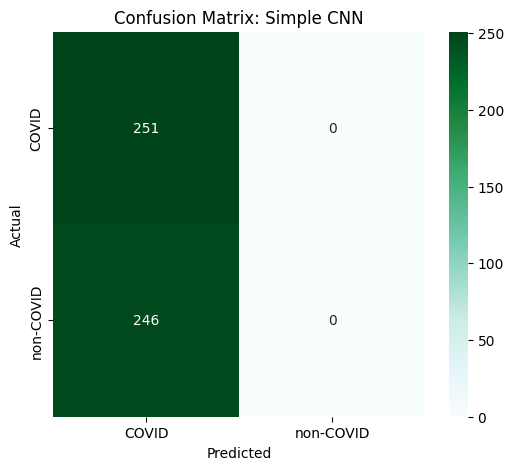

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step


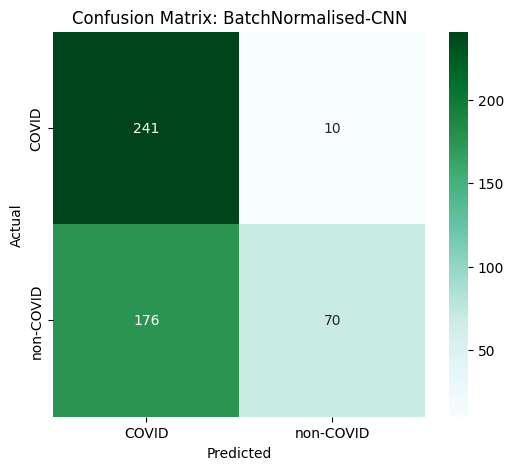

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step


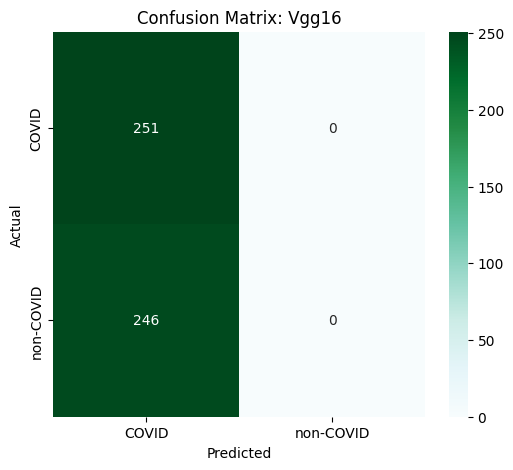

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 306ms/step


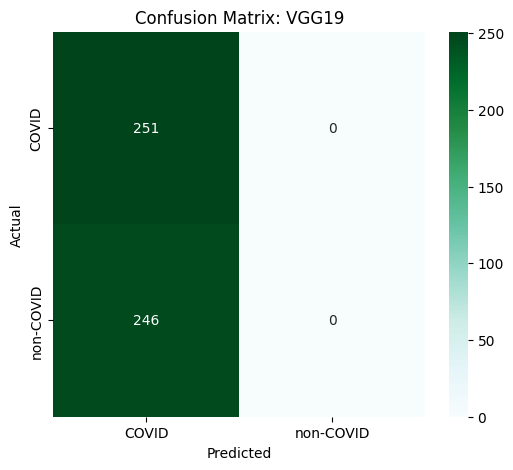

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 213ms/step


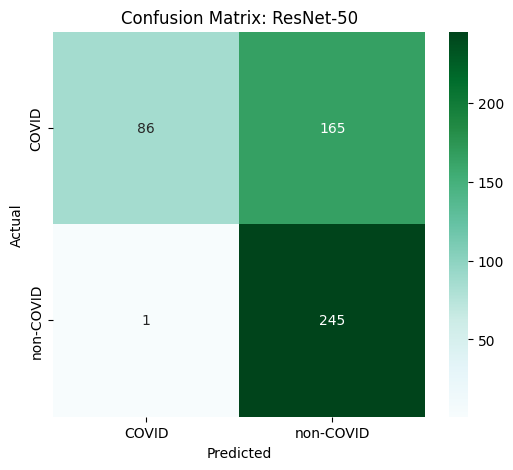

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 206ms/step


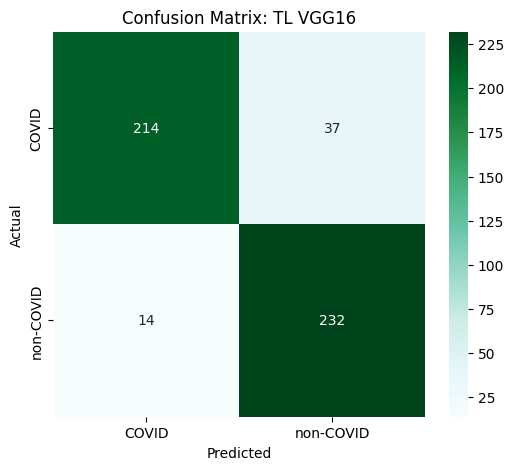

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 255ms/step


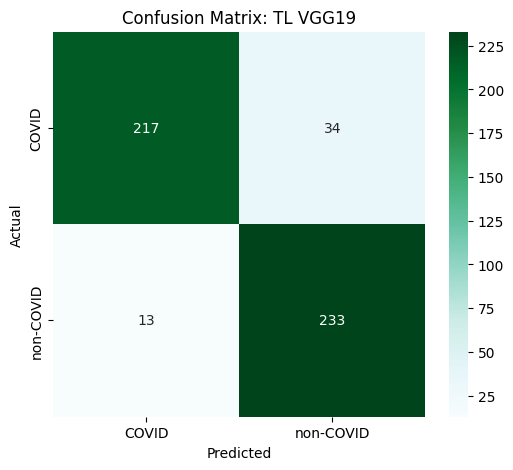

------------------------------
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 150ms/step


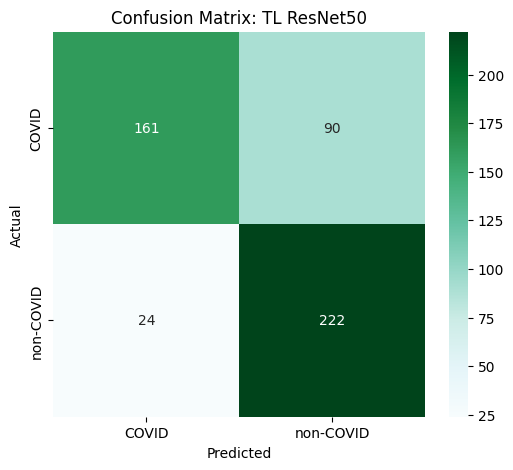

------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

test_gen = test_generator
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())


models_to_test = [CNN1, CNN2, Vgg16, vgg19, resnet50, vgg16tl, vgg19tl, ResNettl]
model_labels = ["Simple CNN", "BatchNormalised-CNN", "Vgg16", "VGG19",
                "ResNet-50", "TL VGG16", "TL VGG19", "TL ResNet50"]


for i, model in enumerate(models_to_test):
    # Create a NEW figure for every model
    plt.figure(figsize=(6, 5))


    preds = model.predict(test_gen, verbose=0)
    test_gen.reset()
    preds = model.predict(test_gen, verbose=1)
    y_pred = np.argmax(preds, axis=1)

    cm = confusion_matrix(y_true, y_pred)


    sns.heatmap(cm, annot=True, fmt='d', cmap='BuGn',
                xticklabels=class_names, yticklabels=class_names)

    plt.title(f"Confusion Matrix: {model_labels[i]}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")


    plt.show()
    print("-" * 30)